In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ayeshasiddiqa123/cars-pre/car_price_prediction_.csv


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("/kaggle/input/datasets/ayeshasiddiqa123/cars-pre/car_price_prediction_.csv")

In [4]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [6]:
df.columns=df.columns.str.lower()

In [7]:
df.drop(columns="car id",inplace=True)

In [8]:
df.isna().sum()

brand           0
year            0
engine size     0
fuel type       0
transmission    0
mileage         0
condition       0
price           0
model           0
dtype: int64

In [9]:
df.describe()

,year,engine size,mileage,price
count,2500.0000,2500.000000,2500.000000,2500.000000
mean,2011.6268,3.465240,149749.844800,52638.022532
std,6.9917,1.432053,87919.952034,27295.833455
min,2000.0000,1.000000,15.000000,5011.270000
25%,2005.0000,2.200000,71831.500000,28908.485000
50%,2012.0000,3.400000,149085.000000,53485.240000
75%,2018.0000,4.700000,225990.500000,75838.532500
max,2023.0000,6.000000,299967.000000,99982.590000


In [10]:
df.duplicated().sum()

np.int64(0)

# EDA

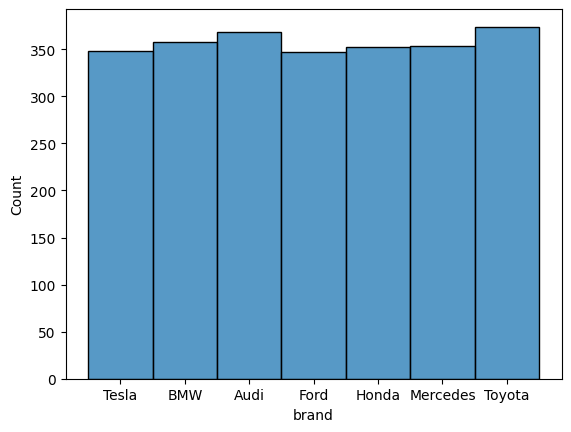

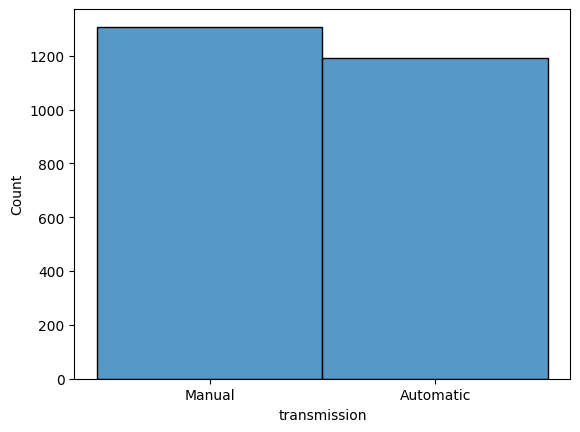

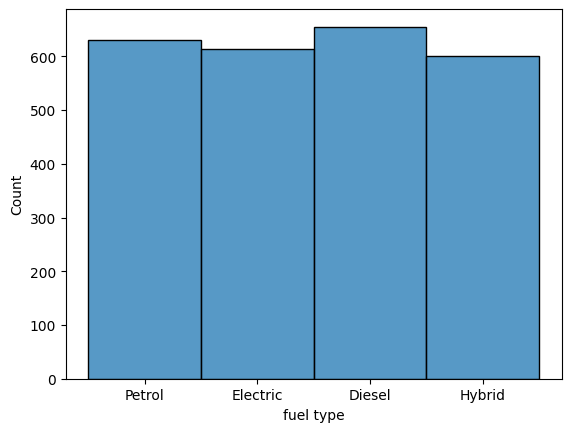

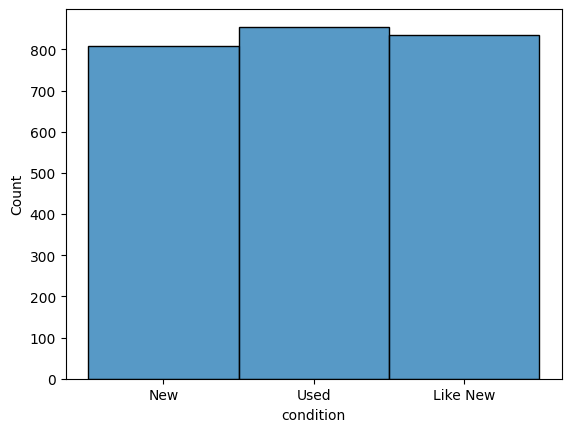

In [11]:
columns=['brand','transmission','fuel type','condition']
for col in columns:
    sns.histplot(x=df[col])
    plt.show()

data is well distributed in categorial columns, which is good for model training.

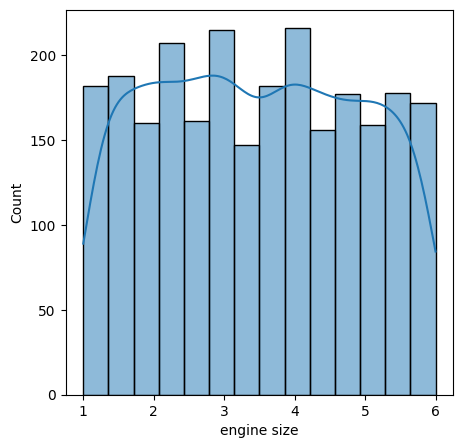

The skewness of the plot is:0.03597200898620086


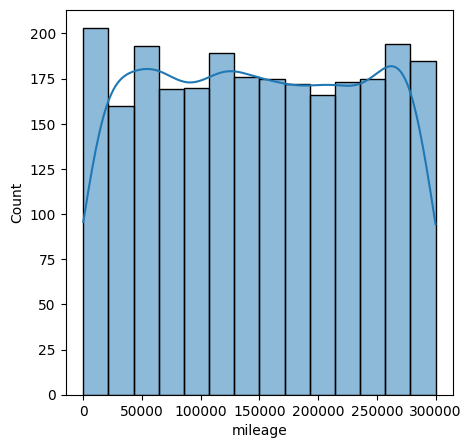

The skewness of the plot is:0.007337410277904952


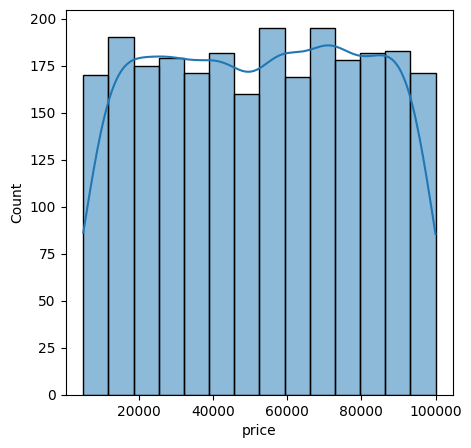

The skewness of the plot is:-0.014483582399920873


In [12]:
columns2=['engine size','mileage','price']
for col in columns2:
    plt.figure(figsize=(5,5))
    sns.histplot(x=df[col],kde=True)
    plt.show()
    print(f"The skewness of the plot is:{df[col].skew()}")


Columns price,engine size and also mileage is having similar size in all the range less chances of ouliers thats good.
the skewness more closer to zero mean more closer to Normality.

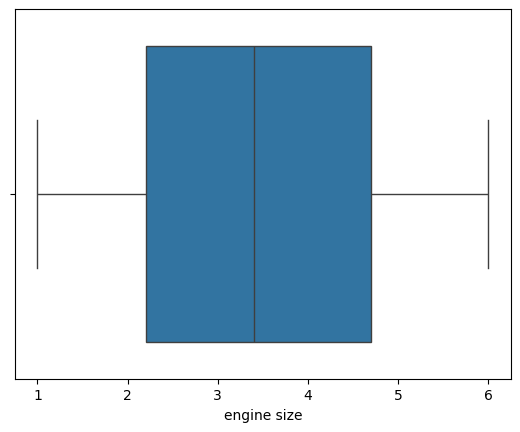

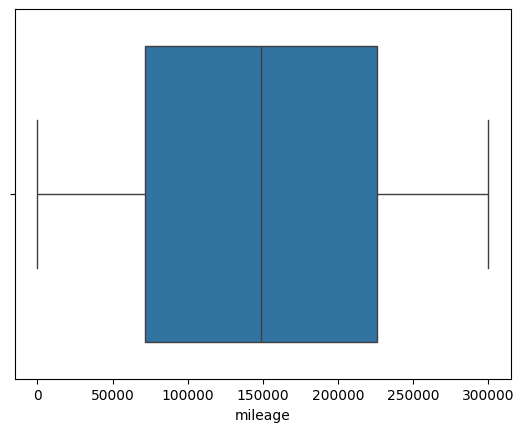

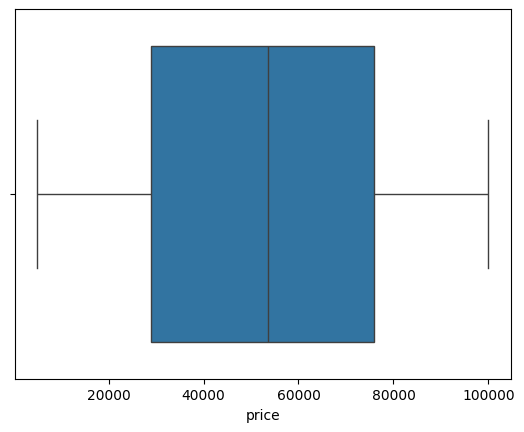

In [13]:
for col in columns2:
    sns.boxplot(x=df[col])
    plt.show()

No outliers, almost perfect distribution between all the quartile.

In [14]:
df.corr(numeric_only=True)

,year,engine size,mileage,price
year,1.000000,0.011833,0.002282,-0.036805
engine size,0.011833,1.000000,-0.015782,-0.004420
mileage,0.002282,-0.015782,1.000000,-0.008567
price,-0.036805,-0.004420,-0.008567,1.000000


Not much corr releation between these parameters suggest as written in dataset description that data is synthesised.

In [15]:
df['model'].value_counts()

model
Fiesta      103
Corolla     103
A3           98
A4           96
Q7           95
CR-V         95
5 Series     93
3 Series     93
Prius        93
Model X      93
C-Class      92
X3           92
GLA          92
Camry        90
E-Class      89
Fit          89
Model Y      89
RAV4         88
Accord       88
Model 3      87
Explorer     86
Focus        81
Civic        80
X5           80
GLC          80
Q5           79
Model S      79
Mustang      77
Name: count, dtype: int64

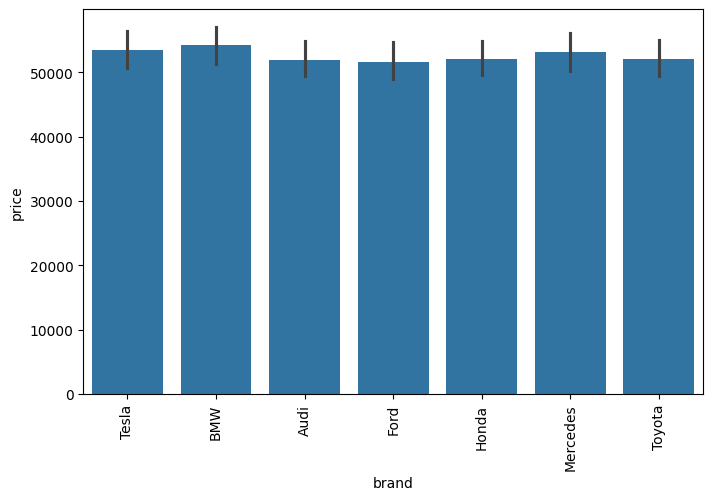

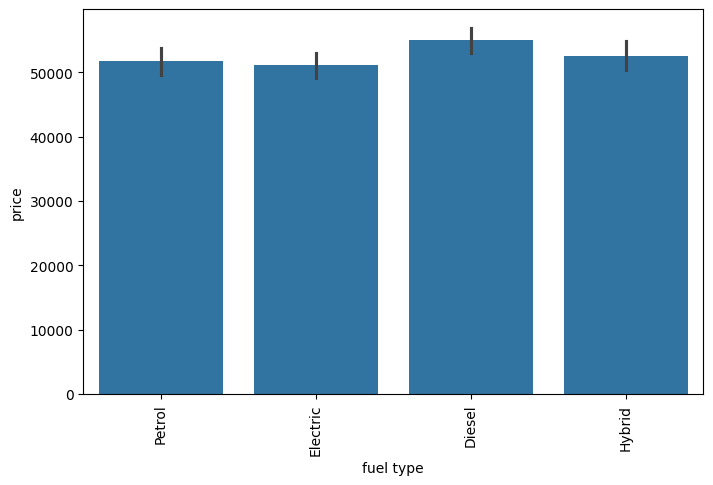

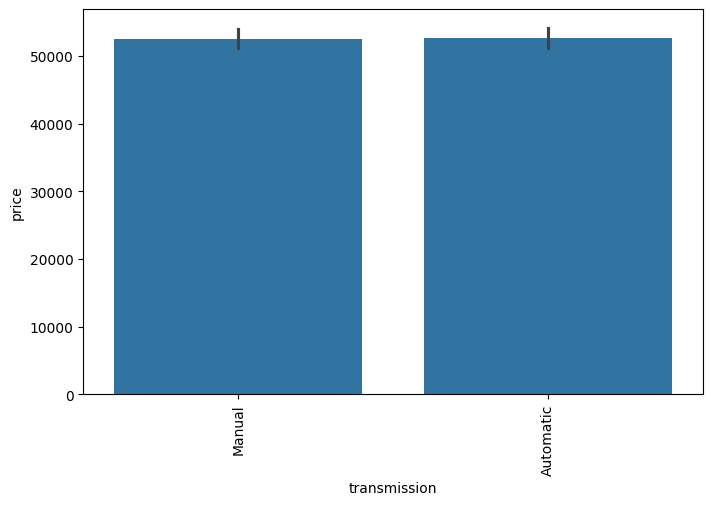

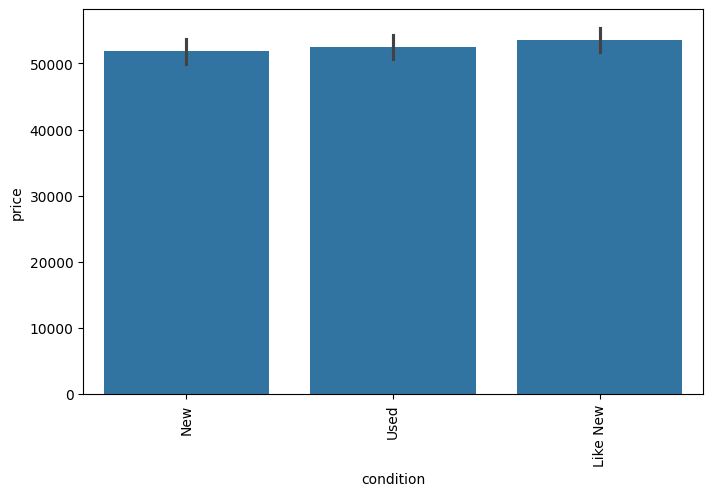

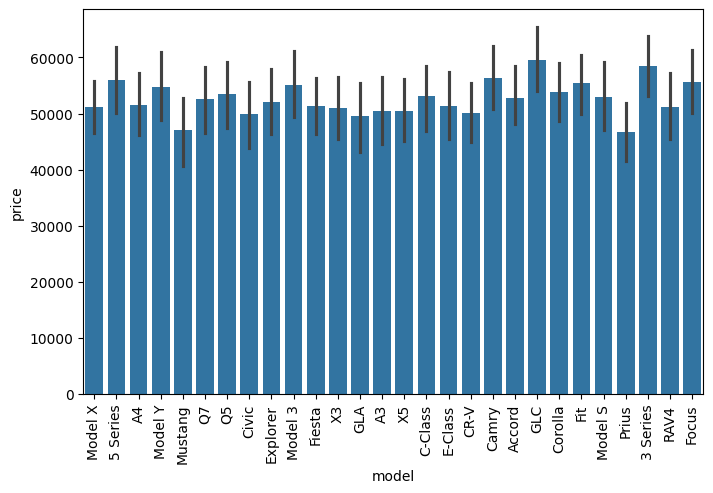

In [16]:
cat_columns=['brand','fuel type','transmission','condition','model']
for col in cat_columns:
    plt.figure(figsize=(8,5))
    sns.barplot(x=df[col],y=df['price'])
    plt.xticks(rotation=90)
    plt.show()

mean price distribution for the categories in columns of cat_columns is almost same except for model which is obvious.

In [17]:
df_copy=pd.get_dummies(df,drop_first=True)

In [18]:
df_copy.head()

,year,engine size,mileage,price,brand_BMW,brand_Ford,brand_Honda,brand_Mercedes,brand_Tesla,brand_Toyota,...,model_Model S,model_Model X,model_Model Y,model_Mustang,model_Prius,model_Q5,model_Q7,model_RAV4,model_X3,model_X5
0,2016,2.3,114832,26613.92,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
1,2018,4.4,143190,14679.61,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2013,4.5,181601,44402.61,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2011,4.1,68682,86374.33,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
4,2009,2.6,223009,73577.10,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [19]:
for col in cat_columns:
    means = df.groupby(col)['price'].mean()
    print(col, means.std())

brand 960.3188621898386
fuel type 1701.1402988291081
transmission 72.52454116502639
condition 818.9953788105621
model 3022.6319274615857


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [21]:
x=df.drop('price',axis=1)
y=df['price']

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [23]:
scaler=StandardScaler()

In [24]:
model=LinearRegression()

In [25]:
a=df_copy.drop('price',axis=1)
b=df['price']

In [26]:
a.head()

,year,engine size,mileage,brand_BMW,brand_Ford,brand_Honda,brand_Mercedes,brand_Tesla,brand_Toyota,fuel type_Electric,...,model_Model S,model_Model X,model_Model Y,model_Mustang,model_Prius,model_Q5,model_Q7,model_RAV4,model_X3,model_X5
0,2016,2.3,114832,False,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
1,2018,4.4,143190,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2013,4.5,181601,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,2011,4.1,68682,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
4,2009,2.6,223009,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [27]:
a.columns

Index(['year', 'engine size', 'mileage', 'brand_BMW', 'brand_Ford',
       'brand_Honda', 'brand_Mercedes', 'brand_Tesla', 'brand_Toyota',
       'fuel type_Electric', 'fuel type_Hybrid', 'fuel type_Petrol',
       'transmission_Manual', 'condition_New', 'condition_Used',
       'model_5 Series', 'model_A3', 'model_A4', 'model_Accord',
       'model_C-Class', 'model_CR-V', 'model_Camry', 'model_Civic',
       'model_Corolla', 'model_E-Class', 'model_Explorer', 'model_Fiesta',
       'model_Fit', 'model_Focus', 'model_GLA', 'model_GLC', 'model_Model 3',
       'model_Model S', 'model_Model X', 'model_Model Y', 'model_Mustang',
       'model_Prius', 'model_Q5', 'model_Q7', 'model_RAV4', 'model_X3',
       'model_X5'],
      dtype='object')

In [28]:
a[['brand_BMW', 'brand_Ford',
       'brand_Honda', 'brand_Mercedes', 'brand_Tesla', 'brand_Toyota',
       'fuel type_Electric', 'fuel type_Hybrid', 'fuel type_Petrol',
       'transmission_Manual', 'condition_New', 'condition_Used',
       'model_5 Series', 'model_A3', 'model_A4', 'model_Accord',
       'model_C-Class', 'model_CR-V', 'model_Camry', 'model_Civic',
       'model_Corolla', 'model_E-Class', 'model_Explorer', 'model_Fiesta',
       'model_Fit', 'model_Focus', 'model_GLA', 'model_GLC', 'model_Model 3',
       'model_Model S', 'model_Model X', 'model_Model Y', 'model_Mustang',
       'model_Prius', 'model_Q5', 'model_Q7', 'model_RAV4', 'model_X3',
       'model_X5']]=a[['brand_BMW', 'brand_Ford',
       'brand_Honda', 'brand_Mercedes', 'brand_Tesla', 'brand_Toyota',
       'fuel type_Electric', 'fuel type_Hybrid', 'fuel type_Petrol',
       'transmission_Manual', 'condition_New', 'condition_Used',
       'model_5 Series', 'model_A3', 'model_A4', 'model_Accord',
       'model_C-Class', 'model_CR-V', 'model_Camry', 'model_Civic',
       'model_Corolla', 'model_E-Class', 'model_Explorer', 'model_Fiesta',
       'model_Fit', 'model_Focus', 'model_GLA', 'model_GLC', 'model_Model 3',
       'model_Model S', 'model_Model X', 'model_Model Y', 'model_Mustang',
       'model_Prius', 'model_Q5', 'model_Q7', 'model_RAV4', 'model_X3',
       'model_X5']].astype(int)

In [29]:
a.head()

,year,engine size,mileage,brand_BMW,brand_Ford,brand_Honda,brand_Mercedes,brand_Tesla,brand_Toyota,fuel type_Electric,...,model_Model S,model_Model X,model_Model Y,model_Mustang,model_Prius,model_Q5,model_Q7,model_RAV4,model_X3,model_X5
0,2016,2.3,114832,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
1,2018,4.4,143190,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2013,4.5,181601,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,2011,4.1,68682,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
4,2009,2.6,223009,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [30]:
a_train,a_test,b_train,b_test=train_test_split(a,b,test_size=0.33,random_state=42)
a_train=scaler.fit_transform(a_train)
a_test=scaler.transform(a_test)

In [31]:
model.fit(a_train,b_train)

LinearRegression()

In [32]:
b_pred=model.predict(a_test)

518.7079064196337


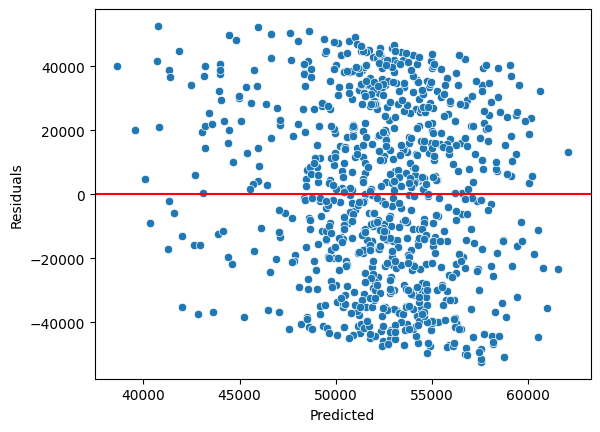

In [33]:
residuals = b_test - b_pred

sns.scatterplot(
    x=b_pred,
    y=residuals
)

plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
print(residuals.mean())

In [34]:
print(r2_score(b_test,b_pred))
print(model.score(a_train,b_train))
print(model.score(a_test,b_test))


-0.020364099621714482
0.02143725092426285
-0.020364099621714482


In [35]:
mae = mean_absolute_error(b_test, b_pred)
print(f"Our predicted price is off by an average of ${mae:.2f}")

mse = mean_squared_error(b_test, b_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

rmse = mse**0.5
print(f"Our predictions are off by approximately ${rmse:.2f} on average (RMSE)")

Our predicted price is off by an average of $24070.39
Mean Squared Error (MSE): 774004435.23
Our predictions are off by approximately $27820.94 on average (RMSE)


# Conclusion


In this project, a car price prediction dataset was analyzed and a Linear Regression model was developed to predict vehicle prices. The dataset was first inspected for missing values, duplicates, and data quality issues before performing exploratory data analysis (EDA).

The EDA revealed that most categorical features such as brand, fuel type, transmission, and condition showed relatively small differences in average vehicle prices, while the model feature exhibited a stronger influence on price. Correlation analysis and visualizations helped identify the relationships between features and the target variable.

The Linear Regression model was trained and evaluated using a train-test split. Model performance was assessed using metrics such as R² score, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE). Residual analysis was also conducted to examine prediction errors and assess model assumptions.

Overall, the project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature encoding, model training, and evaluation. Future improvements may include feature engineering, hyperparameter tuning, cross-validation, and experimenting with more advanced models such as Decision Trees, Random Forests, and Gradient Boosting algorithms to improve predictive performance.


Data is synthesised therefore there is no good prediction of our car's price from this dataset.